<a href="https://colab.research.google.com/github/NooraZhang/IBD-diet-and-inflammation-analysis/blob/main/IBDMDB_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="font-size: 50px;">Dietary Intake and Inflammatory Activity in IBD</h1>

## Research Question
Is dietary intake associated with intestinal inflammation severity, as measured by fecal calprotectin?

## Data Source
The metadata were obtained from the Inflammatory Bowel Disease Multi-omics Database (IBDMDB). Each participant was followed longitudinally, so one participant may contribute observations from multiple visits.

# IBDMDB

IBDMDB is a dataset that contains information about the patient’s food intake, microbiome compositions, patient’s personal information and the inflammation indexes. It is used to record the status and severity of inflammation for different IBD patients.

#Import the file


In [1]:
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "lotas-ai/hutlab-demo/"
    "9189026f2cb66883690c57ad73ad9d96b02a861c/"
    "data/hmp2_metadata_2018-08-20.csv"
)

df_raw = pd.read_csv(DATA_URL, low_memory=False)

print("Raw dataset shape:", df_raw.shape)

assert df_raw.shape == (5533, 490), (
    f"Unexpected dataset shape: {df_raw.shape}"
)

Raw dataset shape: (5533, 490)


In [2]:
df = df_raw.copy()
print(df.shape)

(5533, 490)


# Eliminate the unuseful variables

The raw IBDMDB metadata contained 5,533 rows and 490 columns. I selected 31 variables relevant to the research question. These included participant characteristics, medication use, dietary intake variables, diagnosis, and inflammation measurements. Fecal calprotectin was selected as the main measure of intestinal inflammation because it reflects inflammation in the gastrointestinal tract and it contains fewer missing values than other inflammation markers.

In [3]:
import pandas as pd
df = df_raw.copy()

columns_to_keep = [
    'Participant ID', 'week_num', 'diagnosis', 'sex', 'race', 'BMI',
    'site_sub_coll',
    'Age at diagnosis', 'Antibiotics',
    'Immunosuppressants (e.g. oral corticosteroids)',
    'fecalcal_ng_ml', 'fecalcal', 'is_inflamed', 'hbi', 'sccai',
    'CRP (mg/L)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df = df[columns_to_keep]
print(df.shape)
print(df.head())

(5533, 32)
  Participant ID  week_num diagnosis     sex   race  BMI site_sub_coll  \
0          C3001       2.0        CD  Female  White  NaN     C3001CSC1   
1          C3001       2.0        CD  Female  White  NaN     C3001CSC2   
2          C3002       0.0        CD  Female  White  NaN     C3002CSC1   
3          C3002       0.0        CD  Female  White  NaN     C3002CSC2   
4          C3002       0.0        CD  Female  White  NaN     C3002CSC3   

   Age at diagnosis Antibiotics  \
0              28.0          No   
1              28.0          No   
2              47.0          No   
3              47.0          No   
4              47.0          No   

  Immunosuppressants (e.g. oral corticosteroids)  ...  \
0                                             No  ...   
1                                             No  ...   
2                                             No  ...   
3                                             No  ...   
4                                             No

# Filter out the samples with no data of fecal calprotectin


Among the 5,533 records, 1,883 had a valid fecal calprotectin value. Records without fecal calprotectin were removed because they could not be used to examine the relationship between diet and inflammation.

In [4]:
inflammation_vars = ['fecalcal', 'fecalcal_ng_ml', 'is_inflamed', 'hbi', 'sccai', 'CRP (mg/L)']

for var in inflammation_vars:
    total = len(df)
    missing = df[var].isna().sum()
    valid = total - missing
    pct_missing = missing/total*100
    print(f"{var}: {valid} valid ({pct_missing:.1f}% missing)")

fecalcal: 1883 valid (66.0% missing)
fecalcal_ng_ml: 121 valid (97.8% missing)
is_inflamed: 881 valid (84.1% missing)
hbi: 2145 valid (61.2% missing)
sccai: 1335 valid (75.9% missing)
CRP (mg/L): 669 valid (87.9% missing)


In [5]:

df_clean2 = df[df['fecalcal'].notna()]
print(df_clean2.shape)
print(df_clean2['diagnosis'].value_counts())
print(df_clean2['fecalcal'].head(10))

(1883, 32)
diagnosis
CD        928
UC        512
nonIBD    443
Name: count, dtype: int64
522    193.89000
523     61.34000
524    115.27000
525     23.20350
526     37.17836
527     48.90000
528    179.22000
529     54.33000
530     15.97901
531     14.51068
Name: fecalcal, dtype: float64


# Print the number of missing data for each variable

In [6]:
# 用fecalcal过滤
df_clean = df[df['fecalcal'].notna()].copy()

# 检查missing values
print(df_clean.isnull().sum())

Participant ID                                                                         0
week_num                                                                               0
diagnosis                                                                              0
sex                                                                                    0
race                                                                                   0
BMI                                                                                 1883
site_sub_coll                                                                          0
Age at diagnosis                                                                     458
Antibiotics                                                                            0
Immunosuppressants (e.g. oral corticosteroids)                                         0
fecalcal_ng_ml                                                                      1883
fecalcal             

# Delete the variables with no data


Variables that were completely missing after this filtering step, including BMI, fecalcal_ng_ml, is_inflamed, and CRP, were also removed.

Records with missing values in any of the 16 dietary variables were excluded. After this complete-case filtering, the analysis contained 1,739 records.

In [7]:


df_clean = df_clean.drop(columns=['BMI', 'fecalcal_ng_ml', 'is_inflamed', 'CRP (mg/L)'])


dietary_cols = [
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df_clean = df_clean.dropna(subset=dietary_cols)
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(1739, 28)
diagnosis
CD        858
UC        468
nonIBD    413
Name: count, dtype: int64


In [8]:
# Convert dietary responses from text to ordinal scores

frequency_map = {
    'No, I did not consume these products in the last 7 days': 0,
    'Within the past 4 to 7 days': 1,
    'Within the past 2 to 3 days': 2,
    'Yesterday, 1 to 2 times': 3,
    'Yesterday, 3 or more times': 4
}

for col in dietary_cols:
    df_clean[col] = df_clean[col].replace(frequency_map)
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors='coerce'
    )



/tmp/ipykernel_877/3922896403.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace(frequency_map)


In [9]:
variables_to_check = dietary_cols + ['fecalcal']

variation_check = (
    df_clean
    .groupby('site_sub_coll')[variables_to_check]
    .nunique(dropna=False)
)

different_samples = variation_check[
    variation_check.gt(1).any(axis=1)
]

print(
    "Collection samples with different diet or fecalcal values:",
    len(different_samples)
)

display(different_samples.head(10))

Collection samples with different diet or fecalcal values: 0


,"Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries","Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)","Red meat (beef, hamburger, pork, lamb)","White meat (chicken, turkey, etc.)","Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)","Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)","Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)","Dairy (milk, cream, ice cream, cheese, cream cheese)","Sweets (pies, jam, chocolate, cake, cookies, etc.)","Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)","Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",Eggs,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna","Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)",Water,"Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)",fecalcal
site_sub_coll,,,,,,,,,,,,,,,,,


# Remove the dulicates of samples


In [10]:
# Save all 1,739 cleaned records
df_clean_all_records = df_clean.copy()

# Keep one row per collection sample for diet–fecalcal analysis
df_clean = (
    df_clean
    .drop_duplicates(
        subset='site_sub_coll',
        keep='first'
    )
    .copy()
)

print("Records before deduplication:", len(df_clean_all_records))
print("Unique collection samples used in analysis:", len(df_clean))

assert len(df_clean) == 582, (
    f"Expected 582 collection samples, but found {len(df_clean)}"
)

Records before deduplication: 1739
Unique collection samples used in analysis: 582


# Remove the non-IBD samples

In [11]:
df_clean_all = df_clean.copy()

# Retain only participants with IBD for the primary analysis
df_clean = df_clean_all[
    df_clean_all["diagnosis"].isin(["CD", "UC"])
].copy()

print("Complete cleaned dataset:", df_clean_all.shape)
print("IBD-only analysis dataset:", df_clean.shape)
print(df_clean["diagnosis"].value_counts())
print("Participants:", df_clean["Participant ID"].nunique())

Complete cleaned dataset: (582, 28)
IBD-only analysis dataset: (456, 28)
diagnosis
CD    294
UC    162
Name: count, dtype: int64
Participants: 74


# Visualization of the distribution of fecalcal

count    456.000000
mean     140.395399
std      116.951244
min        3.450000
25%       22.273857
50%      128.200000
75%      228.302500
max      493.700000
Name: fecalcal, dtype: float64


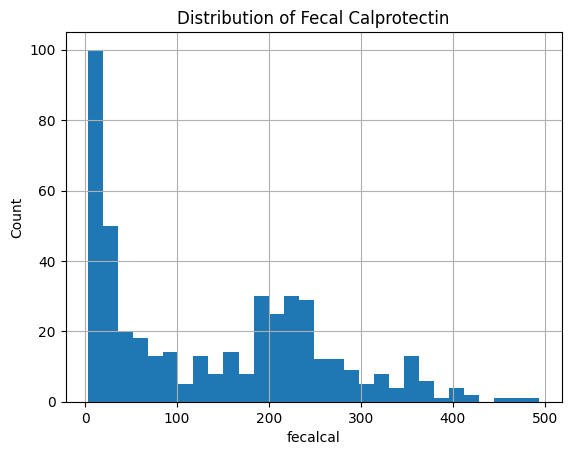

In [12]:
print(df_clean['fecalcal'].describe())

import matplotlib.pyplot as plt
df_clean['fecalcal'].hist(bins=30)
plt.title('Distribution of Fecal Calprotectin')
plt.xlabel('fecalcal')
plt.ylabel('Count')
plt.show()

Fecal calprotectin had a right-skewed distribution. The median value was 54.74 μg/g, while the mean was 116.57 μg/g. This difference indicates that a smaller number of records with high fecal calprotectin values increased the mean. The observed values ranged from 3.45 to 493.70 μg/g.

# Log-transformed visualization of the distribution of fecalcal

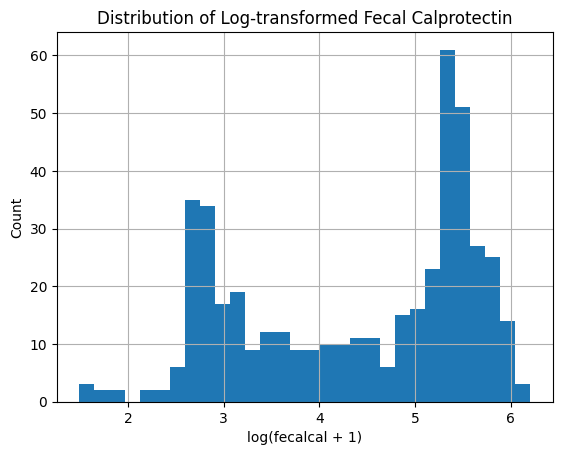

In [13]:
import numpy as np

# Log transformation
df_clean['fecalcal_log'] = np.log(df_clean['fecalcal'] + 1)


df_clean['fecalcal_log'].hist(bins=30)
plt.title('Distribution of Log-transformed Fecal Calprotectin')
plt.xlabel('log(fecalcal + 1)')
plt.ylabel('Count')
plt.show()

A log-transformed graph is generated to show the distribution of fecal calprotectin more clearly. It shows that there are two peak values. The first peak value would be participants who have low level of fecal calprotectin, while the second one may indicate the participants who are experiencing a flare-up period of IBD.

# Print the number of samples from CD and UC patients

In [14]:
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(456, 29)
diagnosis
CD    294
UC    162
Name: count, dtype: int64


In [15]:
sample_counts = df_clean['site_sub_coll'].value_counts()

print("Total rows:", len(df_clean))
print("Unique collection samples:", df_clean['site_sub_coll'].nunique())
print("Samples appearing more than once:", (sample_counts > 1).sum())
print("Maximum repetitions:", sample_counts.max())

display(sample_counts.head(10))

Total rows: 456
Unique collection samples: 456
Samples appearing more than once: 0
Maximum repetitions: 1


,count
site_sub_coll,
M2034C3,1
C3001C1,1
C3001C5,1
C3001C9,1
C3001C15,1
C3001C20,1
C3002C1,1
C3002C5,1
M2010C10,1


#Result of the Spearman statistical test

---



Dietary intake was recorded as an ordinal categorical variable. I converted the categories into numerical scores from 0 to 4 according to their order.

Spearman correlation test was carried out in order to investigate the assosiation between food and fecal calprotectin. Correlation is used to show the relationship between food and fecal calprotectin. A positive value indicates that the intake of the food is associated with increased level of fecal calprotectin, while a negative value indicates that the intake of the food is associated with a decreased level of fecal calprotectin.

P-value is used to indicate whether the correlation between food and fecal calprotecitn is statistically significant (p < 0.05：statistically significant,
p ≥ 0.05：not statistically significant).

In [16]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# 每次运行时清空旧结果
results = []

for col in dietary_cols:
    temp = df_clean[[col, 'fecalcal']].dropna()

    corr, pval = spearmanr(
        temp[col],
        temp['fecalcal']
    )

    results.append({
        'Food': col,
        'Correlation': corr,
        'P-value': pval
    })

# 重新创建，而不是追加到旧表
results_df = pd.DataFrame(results)

# Bonferroni correction（共16次检验）
results_df['Adjusted P-value'] = multipletests(
    results_df['P-value'],
    method='bonferroni'
)[1]

results_df['Significant'] = np.where(
    results_df['Adjusted P-value'] < 0.05,
    'Yes',
    'No'
)

results_df = results_df.sort_values(
    'Correlation',
    ascending=False
).reset_index(drop=True)

print("Number of tests:", len(results_df))

display(
    results_df.style.format({
        'Correlation': '{:.3f}',
        'P-value': '{:.4g}',
        'Adjusted P-value': '{:.4g}'
    })
)

Number of tests: 16


,Food,Correlation,P-value,Adjusted P-value,Significant
0,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna",0.099,0.0348,0.5568,No
1,"Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)",0.046,0.3221,1,No
2,"Dairy (milk, cream, ice cream, cheese, cream cheese)",0.017,0.7217,1,No
3,"Sweets (pies, jam, chocolate, cake, cookies, etc.)",0.009,0.8449,1,No
4,Eggs,-0.013,0.7884,1,No
5,"Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)",-0.015,0.7446,1,No
6,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",-0.043,0.36,1,No
7,"White meat (chicken, turkey, etc.)",-0.075,0.1085,1,No
8,"Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)",-0.086,0.06558,1,No
9,"Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",-0.105,0.02536,0.4058,No


# Visualization of the Spearman Correlation Results (Only Dietary Variables Significantly Associated with Fecal Calprotectin Are Included)

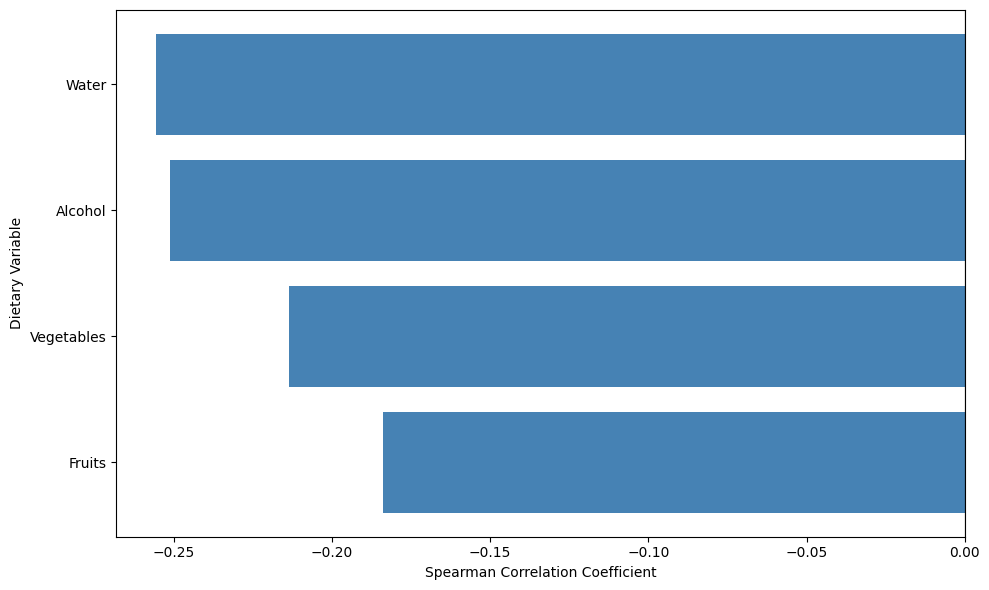

In [17]:
import matplotlib.pyplot as plt

# Select significant Spearman results
sig_results = results_df.loc[
    results_df["Adjusted P-value"] < 0.05,
    ["Food", "Correlation"]
].copy()

# Match names according to their text rather than column position
food_labels = [
    "Processed meat",
    "Soft drinks",
    "Whole grains",
    "White meat",
    "Red meat",
    "Vegetables",
    "Fruits",
    "Alcohol",
    "Yogurt",
    "Starch",
    "Sweets",
    "Dairy",
    "Beans",
    "Eggs",
    "Fish",
    "Water"
]

def shorten_food_name(full_name):
    for label in food_labels:
        if full_name.startswith(label):
            return label
    return full_name

sig_results["Food_short"] = (
    sig_results["Food"]
    .apply(shorten_food_name)
)

# Strongest negative correlations at the top
sig_results = sig_results.sort_values("Correlation")

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in sig_results["Correlation"]
]

ax.barh(
    sig_results["Food_short"],
    sig_results["Correlation"],
    color=colors
)

ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)

# No embedded title because the APA figure title goes above the image in Word
ax.set_xlabel("Spearman Correlation Coefficient")
ax.set_ylabel("Dietary Variable")

plt.tight_layout()

plt.savefig(
    "significant_spearman_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Group the samples into high inflammation level，gray zone and low inflammation level

The samples were categorized into three groups based on the value of fecal calprotectin: low inflammation (<50 μg/g), gray zone (50–250 μg/g), and high inflammation (>250 μg/g).

In [18]:
import numpy as np

df_clean["inflammation_level"] = np.select(
    [
        df_clean["fecalcal"] < 50,
        (df_clean["fecalcal"] >= 50) &
        (df_clean["fecalcal"] <= 250),
        df_clean["fecalcal"] > 250
    ],
    [
        "Low",
        "Gray Zone",
        "High"
    ],
    default="Missing"
)


group_order = ["Low", "Gray Zone", "High"]

df_clean["inflammation_level"] = pd.Categorical(
    df_clean["inflammation_level"],
    categories=group_order,
    ordered=True
)

print(df_clean["inflammation_level"].value_counts().sort_index())

inflammation_level
Low          169
Gray Zone    208
High          79
Name: count, dtype: int64


## Compare Mean Dietary Frequency Scores Across Inflammation Groups

This score shows how frequently each food was consumed, on average, within each inflammation group.

In [19]:
# Calculate mean dietary frequency scores for each group
diet_by_inflammation = (
    df_clean
    .dropna(subset=["inflammation_level"])
    .groupby(
        "inflammation_level",
        observed=True
    )[dietary_cols]
    .mean()
    .reindex(group_order)
    .round(2)
)

print(diet_by_inflammation)

                    Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries  \
inflammation_level                                                                                    
Low                                                              2.36                                 
Gray Zone                                                        2.00                                 
High                                                             1.91                                 

                    Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
inflammation_level                                                                                     
Low                                                              2.76                                  
Gray Zone                                                        2.42                                  
High                                                             2.1

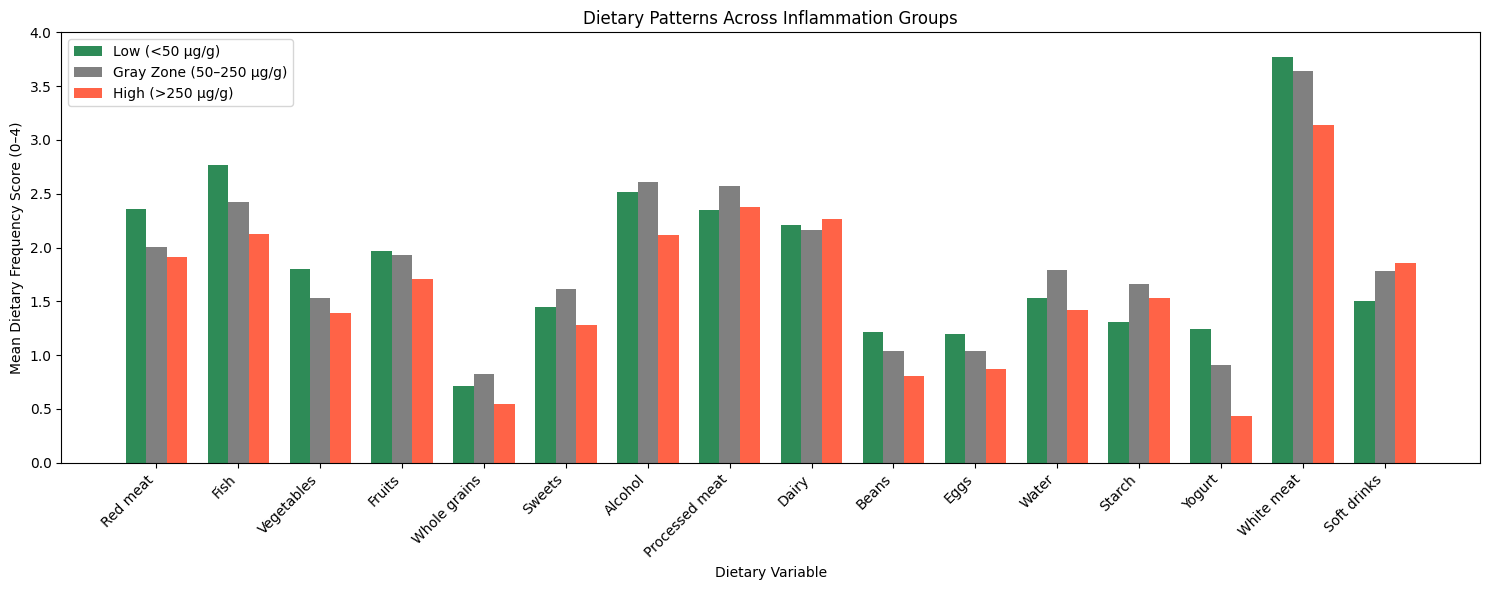

In [20]:
import matplotlib.pyplot as plt
import numpy as np

group_order = ["Low", "Gray Zone", "High"]

diet_by_inflammation = (
    df_clean
    .groupby("inflammation_level", observed=True)[dietary_cols]
    .mean()
    .reindex(group_order)
)

food_short = [
    "Red meat", "Fish", "Vegetables", "Fruits",
    "Whole grains", "Sweets", "Alcohol", "Processed meat",
    "Dairy", "Beans", "Eggs", "Water",
    "Starch", "Yogurt", "White meat", "Soft drinks"
]

x = np.arange(len(food_short))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(
    x - width,
    diet_by_inflammation.loc["Low"],
    width,
    label="Low (<50 μg/g)",
    color="seagreen"
)

ax.bar(
    x,
    diet_by_inflammation.loc["Gray Zone"],
    width,
    label="Gray Zone (50–250 μg/g)",
    color="gray"
)

ax.bar(
    x + width,
    diet_by_inflammation.loc["High"],
    width,
    label="High (>250 μg/g)",
    color="tomato"
)

ax.set_title("Dietary Patterns Across Inflammation Groups")
ax.set_xlabel("Dietary Variable")
ax.set_ylabel("Mean Dietary Frequency Score (0–4)")
ax.set_xticks(x)
ax.set_xticklabels(food_short, rotation=45, ha="right")
ax.set_ylim(0, 4)
ax.legend()

plt.tight_layout()
plt.show()

# Kruskal-Wallis test between three groups of participants with different inflammation level and their food intake

In [21]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

group_order = [
    'Low',
    'Gray Zone',
    'High'
]

kw_results = []

for food in dietary_cols:

    groups = [
        df_clean.loc[
            df_clean['inflammation_level'] == group,
            food
        ].dropna()

        for group in group_order
    ]

    h_stat, p_value = kruskal(*groups)

    kw_results.append({
        'Food': food,
        'H statistic': h_stat,
        'P-value': p_value
    })

kw_results_df = pd.DataFrame(kw_results)

# Bonferroni correction for 16 tests
kw_results_df['Adjusted P-value'] = multipletests(
    kw_results_df['P-value'],
    method='bonferroni'
)[1]

kw_results_df['Significant'] = np.where(
    kw_results_df['Adjusted P-value'] < 0.05,
    'Yes',
    'No'
)

kw_results_df = (
    kw_results_df
    .sort_values('Adjusted P-value')
    .reset_index(drop=True)
)

print("Number of tests:", len(kw_results_df))

display(
    kw_results_df.style.format({
        'H statistic': '{:.3f}',
        'P-value': '{:.4g}',
        'Adjusted P-value': '{:.4g}'
    })
)

Number of tests: 16


,Food,H statistic,P-value,Adjusted P-value,Significant
0,Water,33.673,4.876e-08,7.801e-07,Yes
1,"Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)",22.297,1.44e-05,0.0002304,Yes
2,"Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)",19.567,5.636e-05,0.0009018,Yes
3,"Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries",14.127,0.0008556,0.01369,Yes
4,"Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)",12.711,0.001738,0.0278,Yes
5,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna",8.796,0.0123,0.1968,No
6,"Red meat (beef, hamburger, pork, lamb)",8.083,0.01757,0.2811,No
7,Eggs,6.702,0.03504,0.5607,No
8,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",6.321,0.0424,0.6784,No
9,"Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)",5.651,0.05928,0.9485,No


# Dunn's post-hoc test that compares the food of intake between two groups each time

In [22]:
%pip -q install scikit-posthocs

In [23]:
import scikit_posthocs as sp
import pandas as pd

# 只选择 Kruskal–Wallis 检验校正后显著的食物
significant_foods = kw_results_df.loc[
    kw_results_df["Significant"] == "Yes",
    "Food"
].tolist()

group_order = ["Low", "Gray Zone", "High"]

dunn_results = {}

for food in significant_foods:

    # 删除该食物或炎症组存在缺失值的行
    temp = df_clean[
        ["inflammation_level", food]
    ].dropna()

    # Dunn's pairwise test，并进行 Bonferroni 校正
    dunn_table = sp.posthoc_dunn(
        temp,
        val_col=food,
        group_col="inflammation_level",
        p_adjust="bonferroni"
    )

    # 按 Low、Gray Zone、High 的顺序排列
    dunn_table = dunn_table.reindex(
        index=group_order,
        columns=group_order
    )

    dunn_results[food] = dunn_table

    print("\nFood:", food)
    display(dunn_table.style.format("{:.4f}"))


Food: Water


,Low,Gray Zone,High
Low,1.0000,0.0881,0.0000
Gray Zone,0.0881,1.0000,0.0001
High,0.0000,0.0001,1.0000



Food: Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)


,Low,Gray Zone,High
Low,1.0000,0.0248,0.0000
Gray Zone,0.0248,1.0000,0.0186
High,0.0000,0.0186,1.0000



Food: Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)


,Low,Gray Zone,High
Low,1.0000,0.0017,0.0002
Gray Zone,0.0017,1.0000,0.4906
High,0.0002,0.4906,1.0000



Food: Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries


,Low,Gray Zone,High
Low,1.0000,0.0041,0.0053
Gray Zone,0.0041,1.0000,1.0000
High,0.0053,1.0000,1.0000



Food: Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)


,Low,Gray Zone,High
Low,1.0000,1.0000,0.0124
Gray Zone,1.0000,1.0000,0.0013
High,0.0124,0.0013,1.0000


# The Dunn's Post-hoc test determined which pairs of groups differed significantly, while these descriptive statistics were used to determine which group reported higher or lower dietary frequency scores. This step did not perform an additional statistical significance test.

In [24]:
group_summary = (
    df_clean
    .groupby("inflammation_level")[significant_foods]
    .agg(["median", "mean", "count"])
    .reindex(["Low", "Gray Zone", "High"])
)

display(group_summary.round(2))

/tmp/ipykernel_877/181924057.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("inflammation_level")[significant_foods]


Water              \
                   median  mean count   
inflammation_level                      
Low                   4.0  3.78   169   
Gray Zone             4.0  3.64   208   
High                  3.0  3.14    79   

                   Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)  \
                                                                               median   
inflammation_level                                                                      
Low                                                               1.0                   
Gray Zone                                                         0.0                   
High                                                              0.0                   

                                \
                    mean count   
inflammation_level               
Low                 1.24   169   
Gray Zone           0.91   208   
High                0.43    79   

                   Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
                                                                                             median   
inflammation_level                                                                                    
Low                                                               3.0                                 
Gray Zone                                                         3.0                                 
High                                                              3.0                                 

                                \
                    mean count   
inflammation_level               
Low                 2.76   169   
Gray Zone           2.42   208   
High                2.13    79   

                   Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries  \
                                                                                            median   
inflammation_level                                                                                   
Low                                                               3.0                                
Gray Zone                                                         2.0                                
High                                                              2.0                                

                                \
                    mean count   
inflammation_level               
Low                 2.36   169   
Gray Zone           2.00   208   
High                1.91    79   

                   Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)  \
                                                                                       median   
inflammation_level                                                                              
Low                                                               3.0                           
Gray Zone                                                         3.0                           
High                                                              2.0                           

                                
                    mean count  
inflammation_level              
Low                 2.51   169  
Gray Zone           2.61   208  
High                2.11    79

# Dietary Differences Across Inflammation Groups: Kruskal–Wallis and Dunn’s Post-hoc Test Results

Kruskal-significant foods:
['Water', 'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)', 'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)', 'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries', 'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)']

Foods with significant Dunn comparisons:
['Water', 'Alcohol', 'Vegetables', 'Fruits', 'Starch']


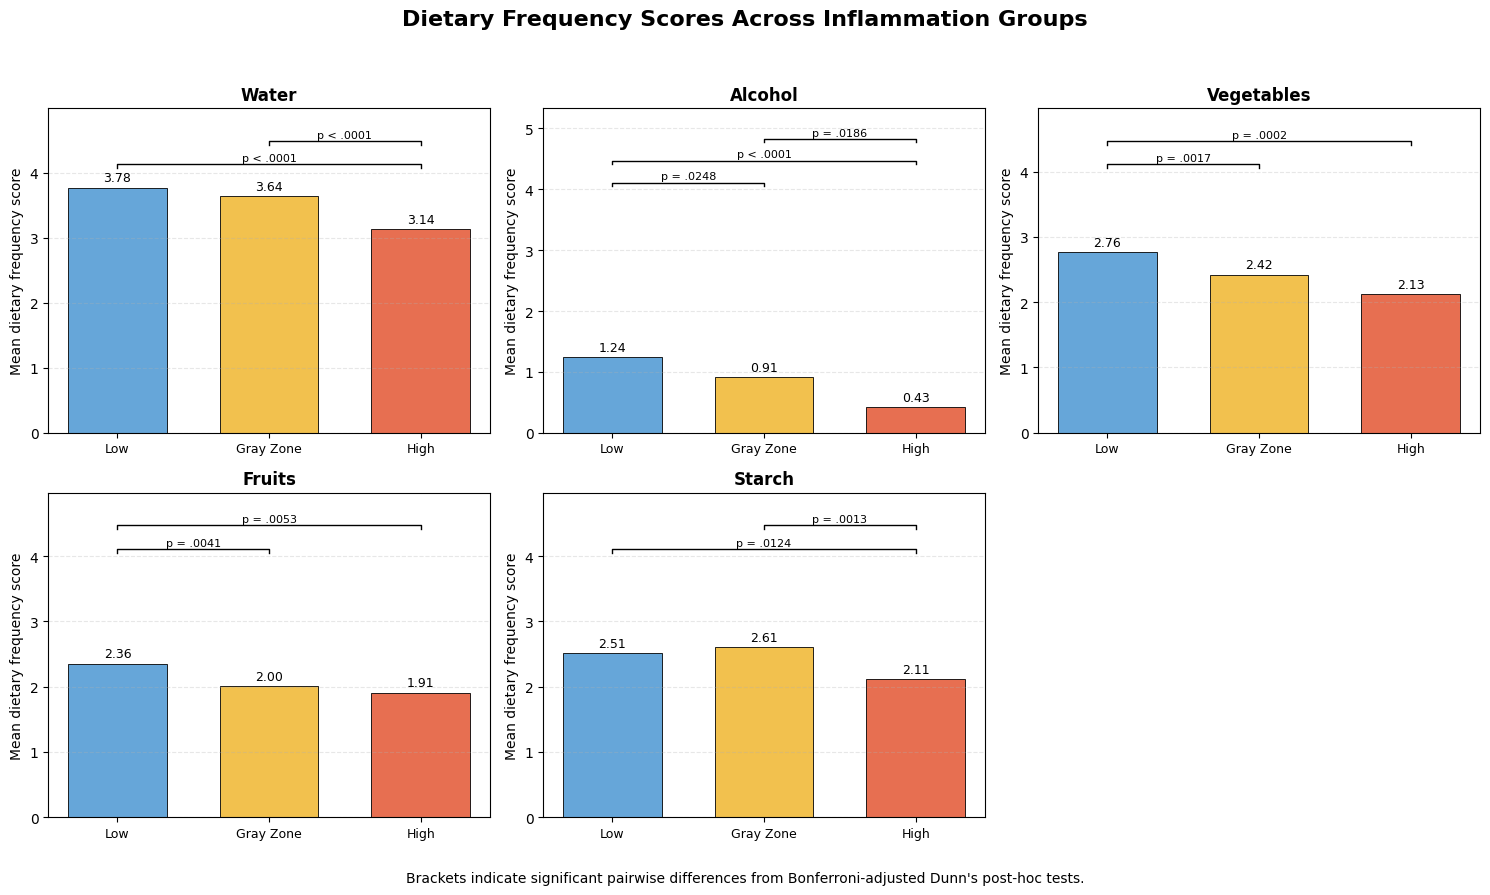

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import scikit_posthocs as sp
import math

# Make sure this is the new IBD-only Kruskal result
print("Kruskal-significant foods:")
print(significant_foods)

group_order = ["Low", "Gray Zone", "High"]

# Short labels for the full dietary column names
food_prefixes = [
    "Vegetables",
    "Water",
    "Fruits",
    "Alcohol",
    "Starch",
    "Yogurt",
    "Red meat",
    "White meat",
    "Fish",
    "Whole grains",
    "Dairy",
    "Sweets",
    "Beans",
    "Eggs",
    "Processed meat",
    "Soft drinks"
]

def get_short_name(full_name):
    for prefix in food_prefixes:
        if full_name.startswith(prefix):
            return prefix
    return full_name.split("(")[0].strip()

# Automatically include all foods significant in the new Kruskal tests
plot_foods = {
    get_short_name(full_name): full_name
    for full_name in significant_foods
}

# Format adjusted p-values for the brackets
def format_p_value(p):
    if p < 0.0001:
        return "p < .0001"

    formatted = f"{p:.4f}"

    if formatted.startswith("0"):
        formatted = formatted[1:]

    return f"p = {formatted}"

# Recalculate Dunn's tests using the current IBD-only df_clean
significant_pairs = {}

for short_name, full_name in plot_foods.items():

    dunn_data = (
        df_clean[
            ["inflammation_level", full_name]
        ]
        .dropna()
        .copy()
    )

    dunn_result = sp.posthoc_dunn(
        dunn_data,
        val_col=full_name,
        group_col="inflammation_level",
        p_adjust="bonferroni"
    )

    pairs = []

    for i in range(len(group_order)):
        for j in range(i + 1, len(group_order)):

            group_1 = group_order[i]
            group_2 = group_order[j]

            if (
                group_1 in dunn_result.index
                and group_2 in dunn_result.columns
            ):
                adjusted_p = dunn_result.loc[group_1, group_2]

                if adjusted_p < 0.05:
                    pairs.append(
                        (
                            i,
                            j,
                            format_p_value(adjusted_p)
                        )
                    )

    if pairs:
        significant_pairs[short_name] = pairs

# Only plot foods with at least one significant Dunn comparison
plot_foods = {
    short_name: full_name
    for short_name, full_name in plot_foods.items()
    if short_name in significant_pairs
}

print("\nFoods with significant Dunn comparisons:")
print(list(plot_foods.keys()))

if len(plot_foods) == 0:
    raise ValueError(
        "No significant Dunn pairwise comparisons were found."
    )

# Function for significance brackets
def add_significance_bracket(ax, x1, x2, y, label):
    bracket_height = 0.06

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bracket_height,
         y + bracket_height, y],
        color="black",
        linewidth=1
    )

    ax.text(
        (x1 + x2) / 2,
        y + bracket_height + 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=8
    )

# Low, Gray Zone, High
colors = ["#66A6D9", "#F2C14E", "#E76F51"]

number_of_plots = len(plot_foods)
number_of_columns = min(3, number_of_plots)
number_of_rows = math.ceil(
    number_of_plots / number_of_columns
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        5 * number_of_columns,
        4.5 * number_of_rows
    ),
    squeeze=False
)

axes = axes.flatten()

for ax, (short_name, full_name) in zip(
    axes,
    plot_foods.items()
):

    means = (
        df_clean
        .groupby(
            "inflammation_level",
            observed=False
        )[full_name]
        .mean()
        .reindex(group_order)
    )

    x_positions = np.arange(len(group_order))

    bars = ax.bar(
        x_positions,
        means.values,
        color=colors,
        width=0.65,
        edgecolor="black",
        linewidth=0.6
    )

    for bar, value in zip(bars, means.values):
        if not np.isnan(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.05,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    pairs = significant_pairs[short_name]

    first_bracket_level = max(
        4.05,
        np.nanmax(means.values) + 0.30
    )

    for pair_number, (x1, x2, p_label) in enumerate(pairs):
        level = first_bracket_level + pair_number * 0.36

        add_significance_bracket(
            ax,
            x1,
            x2,
            level,
            p_label
        )

    upper_limit = (
        first_bracket_level
        + len(pairs) * 0.36
        + 0.20
    )

    ax.set_title(
        short_name,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(group_order, fontsize=9)

    ax.set_ylim(0, upper_limit)
    ax.set_ylabel(
        "Mean dietary frequency score",
        fontsize=10
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

# Hide unused subplot spaces
for ax in axes[number_of_plots:]:
    ax.axis("off")

fig.suptitle(
    "Dietary Frequency Scores Across Inflammation Groups",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5,
    0.01,
    "Brackets indicate significant pairwise differences from "
    "Bonferroni-adjusted Dunn's post-hoc tests.",
    ha="center",
    fontsize=10
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.95]
)

plt.savefig(
    "dunn_posthoc_group_comparison_IBD_only.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

This graph shows the result of the Kruskal-Wallis test and the Dunn's test. The Krusal-Wallis test is used to determine which foods have statistically significant variance across the three groups of patients. Only the food with the frequency score that varies significantly between three groups of patients are kept. After that, tbe mean dietary frequency scores of these foods are calculated. Dunn's test is used to determine that variation of mean frequency score of a food across two groups. Only the variations that are statistically significant are shown in the graph as brackets and p-values.

#Linear Regression Model

 This model was used to investigate the linear relationship between the diet and the inflammation level.

In [26]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# --------------------------------------------------
# 1. Identify the participant ID column
# --------------------------------------------------

participant_candidates = [
    "Participant ID",
    "participant_id",
    "subject_id"
]

participant_col = next(
    (
        col for col in participant_candidates
        if col in df_clean.columns
    ),
    None
)

if participant_col is None:
    raise ValueError(
        "Participant ID column was not found. "
        "Please check the column name."
    )

# --------------------------------------------------
# 2. Select available control variables
# --------------------------------------------------

numeric_control_candidates = [
    "week_num",
    "Age at diagnosis"
]

categorical_control_candidates = [
    "diagnosis",
    "sex",
    "race",
    "Antibiotics",
    "Immunosuppressants (e.g. oral corticosteroids)"
]
numeric_controls = [
    col for col in numeric_control_candidates
    if col in df_clean.columns
]

categorical_controls = [
    col for col in categorical_control_candidates
    if col in df_clean.columns
]

print("Participant column:", participant_col)
print("Numeric controls:", numeric_controls)
print("Categorical controls:", categorical_controls)

# --------------------------------------------------
# 3. Prepare the regression dataset
# --------------------------------------------------

numeric_predictors = dietary_cols + numeric_controls
all_predictors = numeric_predictors + categorical_controls

model_df = df_clean[
    [participant_col, "fecalcal"] + all_predictors
].copy()

# Convert dietary scores and continuous controls to numeric
for col in numeric_predictors + ["fecalcal"]:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

# Remove rows without outcome or participant ID
model_df = model_df.dropna(
    subset=[participant_col, "fecalcal"]
)

# Fecal calprotectin cannot be negative
model_df = model_df[
    model_df["fecalcal"] >= 0
].copy()

# Log-transform the continuous outcome
model_df["log_fecalcal"] = np.log1p(
    model_df["fecalcal"]
)

X = model_df[all_predictors]
y = model_df["log_fecalcal"]
groups = model_df[participant_col]

print("Number of samples:", len(model_df))
print("Number of participants:", groups.nunique())

# --------------------------------------------------
# 4. Preprocess numeric and categorical variables
# --------------------------------------------------

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

transformers = [
    (
        "numeric",
        numeric_pipeline,
        numeric_predictors
    )
]

if categorical_controls:
    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False

            )
        )
    ])

    transformers.append(
        (
            "categorical",
            categorical_pipeline,
            categorical_controls
        )
    )

preprocessor = ColumnTransformer(
    transformers=transformers
)

# --------------------------------------------------
# 5. Create the Ridge linear regression model
# --------------------------------------------------

ridge_model = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "ridge",
        Ridge(alpha=1.0)
    )
])

# --------------------------------------------------
# 6. Grouped cross-validation by participant
# --------------------------------------------------

n_splits = min(5, groups.nunique())

if n_splits < 2:
    raise ValueError(
        "At least two participants are required."
    )

group_cv = GroupKFold(
    n_splits=n_splits
)

predicted_log_fecalcal = cross_val_predict(
    ridge_model,
    X,
    y,
    groups=groups,
    cv=group_cv
)

# --------------------------------------------------
# 7. Evaluate model performance
# --------------------------------------------------

r2 = r2_score(
    y,
    predicted_log_fecalcal
)

mae = mean_absolute_error(
    y,
    predicted_log_fecalcal
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        predicted_log_fecalcal
    )
)

print("\nGrouped cross-validation results")
print("--------------------------------")
print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# --------------------------------------------------
# 8. Fit the model on all available data
# --------------------------------------------------

ridge_model.fit(X, y)

feature_names = (
    ridge_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

coefficients = (
    ridge_model
    .named_steps["ridge"]
    .coef_
)

coefficient_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients
})

# Remove pipeline prefixes from variable names
coefficient_df["Variable"] = (
    coefficient_df["Variable"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_df["Absolute coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "Absolute coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    coefficient_df[
        ["Variable", "Coefficient"]
    ].round(3)
)

Participant column: Participant ID
Numeric controls: ['week_num', 'Age at diagnosis']
Categorical controls: ['diagnosis', 'sex', 'race', 'Antibiotics', 'Immunosuppressants (e.g. oral corticosteroids)']
Number of samples: 456
Number of participants: 74


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Grouped cross-validation results
--------------------------------
R²:   -0.054
MAE:  1.051
RMSE: 1.230


,Variable,Coefficient
0,race_Other,-1.485
1,race_More than one race,-0.309
2,sex_Male,0.302
3,Water,-0.267
4,Antibiotics_Yes,-0.256
5,Immunosuppressants (e.g. oral corticosteroids)...,0.244
6,week_num,-0.220
7,race_Black or African American,0.205
8,"Red meat (beef, hamburger, pork, lamb)",-0.186
9,"Alcohol (beer, brandy, spirits, hard liquor, w...",-0.172


# Random Forest Model

In [27]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ==================================================
# 1. Use exactly the same predictors for both models
# ==================================================

participant_col = "Participant ID"

numeric_controls = [
    "week_num",
    "Age at diagnosis"
]

categorical_controls = [
    "diagnosis",
    "sex",
    "race",
    "Antibiotics",
    "Immunosuppressants (e.g. oral corticosteroids)"
]

numeric_predictors = dietary_cols + numeric_controls
all_predictors = numeric_predictors + categorical_controls

model_df = df_clean[
    [participant_col, "fecalcal"] + all_predictors
].copy()

# Convert numeric variables
for column in numeric_predictors + ["fecalcal"]:
    model_df[column] = pd.to_numeric(
        model_df[column],
        errors="coerce"
    )

# Remove observations without outcome or participant ID
model_df = model_df.dropna(
    subset=[participant_col, "fecalcal"]
)

model_df = model_df[
    model_df["fecalcal"] >= 0
].copy()

# Same outcome for both models
model_df["log_fecalcal"] = np.log1p(
    model_df["fecalcal"]
)

X = model_df[all_predictors]
y = model_df["log_fecalcal"]
groups = model_df[participant_col]

print("Number of samples:", len(model_df))
print("Number of participants:", groups.nunique())
print("Number of predictors before encoding:", len(all_predictors))

# ==================================================
# 2. Same preprocessing for both models
# ==================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_predictors
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_controls
    )
])

# ==================================================
# 3. Define Ridge and Random Forest
# ==================================================

ibd_model_data = df_clean[
    df_clean["diagnosis"].isin(["CD", "UC"])
].copy()

numeric_predictors = dietary_cols + numeric_controls
all_predictors = numeric_predictors + categorical_controls

model_df = ibd_model_data[
    [participant_col, "fecalcal"] + all_predictors
].copy()
ridge_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        Ridge(alpha=1.0)
    )
])

random_forest_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
    )
])

# ==================================================
# 4. Create identical participant-grouped folds
# ==================================================

group_cv = GroupKFold(n_splits=5)

cv_splits = list(
    group_cv.split(
        X,
        y,
        groups=groups
    )
)

# Confirm that no participant appears in both sets
for fold_number, (train_index, test_index) in enumerate(
    cv_splits,
    start=1
):
    train_participants = set(
        groups.iloc[train_index]
    )

    test_participants = set(
        groups.iloc[test_index]
    )

    overlap = (
        train_participants &
        test_participants
    )

    print(
        f"Fold {fold_number}: "
        f"participant overlap = {len(overlap)}"
    )

# ==================================================
# 5. Evaluate both models on identical folds
# ==================================================

models = {
    "Ridge regression": ridge_pipeline,
    "Random Forest": random_forest_pipeline
}

comparison_results = []

model_predictions = {}

for model_name, model in models.items():

    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=cv_splits
    )

    model_predictions[model_name] = predictions

    r2 = r2_score(
        y,
        predictions
    )

    mae = mean_absolute_error(
        y,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            predictions
        )
    )

    comparison_results.append({
        "Model": model_name,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse
    })

model_comparison_df = pd.DataFrame(
    comparison_results
)

display(
    model_comparison_df.style.format({
        "R²": "{:.3f}",
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}"
    })
)

Number of samples: 456
Number of participants: 74
Number of predictors before encoding: 23
Fold 1: participant overlap = 0
Fold 2: participant overlap = 0
Fold 3: participant overlap = 0
Fold 4: participant overlap = 0
Fold 5: participant overlap = 0


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,R²,MAE,RMSE
0,Ridge regression,-0.054,1.051,1.230
1,Random Forest,0.011,1.039,1.192


# Result of the Random Forest Model

In [28]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Store permutation importance from each test fold
fold_importance_results = []

for fold_number, (train_index, test_index) in enumerate(
    cv_splits,
    start=1
):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Create a separate Random Forest for each fold
    fold_model = clone(
        random_forest_pipeline
    )

    fold_model.fit(
        X_train,
        y_train
    )

    # Importance is calculated only on the held-out test fold
    permutation_result = permutation_importance(
        fold_model,
        X_test,
        y_test,
        scoring="r2",
        n_repeats=10,
        random_state=42 + fold_number,
        n_jobs=-1
    )

    fold_result = pd.DataFrame({
        "Variable": X.columns,
        "Importance": permutation_result.importances_mean,
        "Fold": fold_number
    })

    fold_importance_results.append(
        fold_result
    )

# Combine results from all five folds
all_fold_importances = pd.concat(
    fold_importance_results,
    ignore_index=True
)

rf_importance_df = (
    all_fold_importances
    .groupby("Variable", as_index=False)
    .agg(
        Mean_importance=("Importance", "mean"),
        SD_importance=("Importance", "std")
    )
    .sort_values(
        "Mean_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_importance_df.style.format({
        "Mean_importance": "{:.4f}",
        "SD_importance": "{:.4f}"
    })
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Variable,Mean_importance,SD_importance
0,week_num,0.0507,0.0137
1,Water,0.0100,0.0296
2,"Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)",0.0094,0.0061
3,"Red meat (beef, hamburger, pork, lamb)",0.0087,0.0122
4,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna",0.0064,0.0129
5,"Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",0.0057,0.0069
6,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",0.0046,0.0083
7,"Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries",0.0017,0.0174
8,"Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)",0.0013,0.0132
9,Immunosuppressants (e.g. oral corticosteroids),0.0005,0.0028
